# Items Prediction Process

## Imports

In [2]:
from elasticsearch import Elasticsearch
import pandas as pd
import numpy as np
import datetime
import keras
import pickle
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
import time

Using TensorFlow backend.


### Predict on batch

To get enough data we take 4 days in consideration and build our testdata from all items, that are still in the last timestamp

#### Establish connection to Elasticsearch

In [4]:
# ignore 400 cause by IndexAlreadyExistsException when creating an index
es = Elasticsearch()
# es = Elasticsearch(
#       ['localhost'],
#       http_auth=(username, 'password'),
#       verify_certs=False,
#       scheme="https",
#       port=443,
# )
es.indices.create(index='queues-prediction', ignore=400) #can be ignored

{'error': {'root_cause': [{'type': 'resource_already_exists_exception',
    'reason': 'index [queues-prediction/D3O1OrPrRqGFs1v3O06EAw] already exists',
    'index_uuid': 'D3O1OrPrRqGFs1v3O06EAw',
    'index': 'queues-prediction'}],
  'type': 'resource_already_exists_exception',
  'reason': 'index [queues-prediction/D3O1OrPrRqGFs1v3O06EAw] already exists',
  'index_uuid': 'D3O1OrPrRqGFs1v3O06EAw',
  'index': 'queues-prediction'},
 'status': 400}

#### Fetch the data from ES 

For example we take 4 days of data 

In [27]:
start = time.time()
d = []
for date in range (21,25):
    res = es.search(index="queues", body={"query" : {
                                            "bool" : { 
                                              "must" : [
                                                {"match": {
                                                        "name" : "products"}},
                                                {"range": {
                                                        "timestamp":{
                                                            "gte": "2019-12-"+str(date),
                                                            "lte": "2019-12-"+str(date),
                                                            "format": "yyyy-MM-dd"
                                                      }
                                                    }
                                                  }
                                              ]
                                            }
                                          }
                                        }, size=1440) #define size
    c = [elem['_source'] for elem in res['hits']['hits']]
    d.extend(c)  
print(time.time() - start)

2.2987399101257324


In [28]:
df = pd.DataFrame(d)
df = df.iloc[::10,:].copy() #take ever 10th entry
df.index = df["timestamp"]
df.index = pd.to_datetime(df.index, format='%Y-%m-%dT%H:%M:%S.%f%z').sort_values()
df.drop(columns=['timestamp', 'name', 'tier'], inplace=True) #drop unnecassry columns
df['items'] = [[str(x)] if len(str(x)) < 10 else str(x).split(" ") for x in df['items']] #convert items to list

After small adjustments we get our initial dataframe

In [29]:
df

,querytime,items,size
timestamp,,,
2019-12-21 00:34:02.785569+00:00,105,"[3729398496, 1140352564, 19527465, 4133442579,...",7363
2019-12-21 00:39:03.625172+00:00,213,"[3729398496, 1140352564, 19527465, 4133442579,...",7388
2019-12-21 00:44:03.833894+00:00,97,"[3729398496, 1140352564, 19527465, 4133442579,...",7418
2019-12-21 00:49:03.812968+00:00,254,"[3729398496, 1140352564, 19527465, 4133442579,...",7447
2019-12-21 00:53:33.947282+00:00,101,"[3729398496, 1140352564, 19527465, 4133442579,...",7479
...,...,...,...
2019-12-24 23:35:04.489744+00:00,196,"[126992010, 2706696355, 2755802835, 4195459787...",6212
2019-12-24 23:40:04.767813+00:00,605,"[126992010, 2706696355, 2755802835, 4195459787...",6107
2019-12-24 23:45:04.513784+00:00,467,"[126992010, 2706696355, 2755802835, 4195459787...",6096


Adding features to it

In [30]:
lists = df['items'].tolist()
current = lists[0]
diff_sets = [[]]
diff_sets_rev = [[]]
for next_list in lists[1:]:
    diff_sets.append(sorted(set(current).difference(set(next_list))))
    diff_sets_rev.append(sorted(set(next_list).difference(set(current))))
    current = next_list

In [31]:
df['diff_items'] = diff_sets
df['diff_items_rev'] = diff_sets_rev
df['n_removed'] = df['diff_items'].apply(lambda x: len(x))
df['n_added'] = df['diff_items_rev'].apply(lambda x: len(x))

Create a multilabelbinarized version of it

In [97]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
df_mlb = pd.DataFrame(mlb.fit_transform(df['items']),columns=mlb.classes_)

In [98]:
def create_dataset(df_binarized, df_overall):
    """ Creates two lists containing the dataset 
    for the features X and the variable target y, 
    based on two dataframes
    
    Parameters:
    df_binarized : a multilabel binarized dataframe
    df_overall : a non binarized dataframe
    
    Returns : 
    X : a list of dataframes enriched with features
    y : a list of target variables - the remaining steps in Q
    """
    
    
    # extract general features   
    # for each item create a corresponding dataset X, y and then concatenate
    
    # cumsum for ascending steps in Q
    Xs = df_binarized.cumsum()
    # reverse, cumsum, reverse again for remaining steps in Q
    Ys = df_binarized.iloc[::-1].cumsum().iloc[::-1]
    
    # get features from df_overall
    Q_sizes = df_overall['size'].values
    #Q_items = df_overall['items'].values
    n_added = df_overall['n_added'].values
    n_removed = df_overall['n_removed'].values
    
    X = list()
    y = list()
    
    for item in df_binarized.columns:
        # for one item select the rows where it is still in Q
        mask = df_binarized[item] != 0
        
        # labels to predict (how many remaining steps in Q)
        Y_item = Ys[item][mask]
        
        # create features (number of steps in Q already in Xs)
        X_item = pd.DataFrame(Xs[item][mask])
        #X_item = X_item.rename(columns = {item: 'n_steps_in_Q'})
        
        # get the Queue sizes
        X_item['Q_size'] = Q_sizes[mask]
        
        # Q difference 
        X_item['n_added'] = n_added[mask]
        X_item['n_removed'] = n_removed[mask]
        X.append(X_item)
        y.append(Y_item)
    return X, y

In [99]:
X, y = create_dataset(df_mlb, df)

Take only the items that are still in the queue at the last timestep

In [153]:
items_pred = df['items'][-1]

In [154]:
X_pred = list()
for item in X:
    if item.columns[0] in items_pred:
        X_pred.append(item)

Padding

In [155]:
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
def pad(sequence, maxlen):
    # fills list post (at the end) with 0s to make even sized sequences
    return pad_sequences(sequence, maxlen=604, dtype='float32', padding='post', value=0.0)

In [192]:
X_pr = pad([x.values for x in X_pred], 604)

### Scaling 

In [157]:
import pickle

In [158]:
scaler_X = pickle.load(open("res_scaler_X_1w.p", "rb"))
scaler_y = pickle.load(open("res_scaler_y_1w.p", "rb"))

In [159]:
from sklearn.preprocessing import StandardScaler

In [160]:
n_tr, ts, d_X = X_pr.shape # n = number of samples, ts = number of Timesteps, d = dimension of input(Features)
X_pr_scaled = scaler_X.fit_transform(X_pr.reshape(n_tr*ts, d_X)).reshape(X_pr.shape)

In [161]:
X_pr_scaled.shape

(5575, 604, 4)

In [173]:
steps_X = list()
for x in X_pr:
    ma = max(x[:,0])
    steps_X.append(ma)

In [174]:
steps_X

[110.0,
 64.0,
 112.0,
 135.0,
 141.0,
 121.0,
 83.0,
 121.0,
 117.0,
 141.0,
 138.0,
 141.0,
 141.0,
 89.0,
 105.0,
 96.0,
 81.0,
 121.0,
 133.0,
 121.0,
 134.0,
 97.0,
 141.0,
 89.0,
 121.0,
 121.0,
 106.0,
 89.0,
 141.0,
 93.0,
 141.0,
 138.0,
 132.0,
 103.0,
 66.0,
 138.0,
 70.0,
 132.0,
 86.0,
 141.0,
 182.0,
 83.0,
 121.0,
 141.0,
 101.0,
 121.0,
 95.0,
 123.0,
 121.0,
 79.0,
 97.0,
 120.0,
 132.0,
 110.0,
 121.0,
 128.0,
 105.0,
 121.0,
 117.0,
 83.0,
 73.0,
 141.0,
 137.0,
 121.0,
 67.0,
 123.0,
 141.0,
 121.0,
 69.0,
 114.0,
 122.0,
 141.0,
 92.0,
 105.0,
 107.0,
 121.0,
 141.0,
 121.0,
 121.0,
 141.0,
 141.0,
 128.0,
 118.0,
 141.0,
 109.0,
 99.0,
 94.0,
 121.0,
 121.0,
 87.0,
 72.0,
 114.0,
 110.0,
 132.0,
 121.0,
 86.0,
 89.0,
 141.0,
 132.0,
 121.0,
 125.0,
 141.0,
 105.0,
 140.0,
 97.0,
 61.0,
 136.0,
 83.0,
 132.0,
 87.0,
 126.0,
 67.0,
 121.0,
 128.0,
 128.0,
 115.0,
 77.0,
 115.0,
 140.0,
 105.0,
 122.0,
 125.0,
 120.0,
 100.0,
 121.0,
 131.0,
 83.0,
 95.0,
 121.0,
 13

## Load Model

In [148]:
from tensorflow.keras.models import load_model

In [149]:
model = load_model("res_model_items_1w.h5")

### Predictions

In [150]:
pred = model.predict(X_pr_scaled)
y_pred = scaler_y.inverse_transform(pred.reshape(-1, 1)).reshape(pred.shape)

### Plots

In [175]:
import matplotlib.pyplot as plt

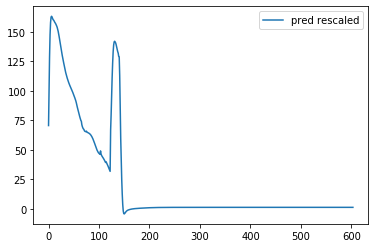

In [176]:
x = np.random.randint(len(pred))
#plt.plot(y_testresc[x], label='true rescaled')
plt.plot(y_pred[x], label='pred rescaled')
plt.legend()
plt.show()

## Target DF

Create lists containing the predictions and corresponding item numbers

In [263]:
pred_list = list()
pred_only = list()
for x in range(len(X_pr)):
    predict = (int(y_pred[x][int(steps_X[x])]))
    item = X_pred[x].columns[0]
    item_predict = [item, predict]
    pred_list.append(item_predict)
    pred_only.append(predict)
    #print(predict)

In [260]:
pred_list

[['100129131', 120],
 ['1002418739', 25],
 ['1003554265', 119],
 ['100372969', 113],
 ['100379732', 112],
 ['100408582', 116],
 ['100473421', 68],
 ['1004792045', 116],
 ['100698586', 117],
 ['1010184859', 112],
 ['1010659933', 113],
 ['1011363666', 112],
 ['1011383264', 112],
 ['1013203303', 144],
 ['1013882072', 129],
 ['1014228064', 137],
 ['1016489542', 76],
 ['1016620438', 116],
 ['1016694698', 114],
 ['1017854769', 116],
 ['1018942485', 113],
 ['1019127297', 74],
 ['1019348969', 112],
 ['1019722492', 71],
 ['1020312007', 116],
 ['1021274966', 116],
 ['1021475786', 112],
 ['1022382839', 144],
 ['1022596002', 112],
 ['1023039109', 72],
 ['1025238120', 112],
 ['1025454661', 113],
 ['1026186569', 114],
 ['1027127775', 92],
 ['1028231445', 25],
 ['1029142930', 113],
 ['1029728238', 26],
 ['1030248980', 114],
 ['1030541888', 68],
 ['1031544813', 112],
 ['1032384185', 104],
 ['1033278706', 68],
 ['1034185132', 116],
 ['1035836966', 112],
 ['1036179256', 83],
 ['1036550114', 116],
 ['103

The final list creates the ES structure for the items

In [266]:
final_list = list()

for x in range(int(max(pred_only))):
    items = ''
    for y in pred_list:
        if y[1] >= x:
            ite = y[0] + ' '
            items += ite
    final_list.append(items)      

The last entry of the list

In [261]:
final_list[143]

'1013203303 1022382839 1060790929 1108443522 1142688942 1274618047 1383937991 139430125 1533007389 1544939956 1559139007 1819060289 1856726549 2016791904 2034846775 2185915792 2195234351 223862001 2284346070 2324945250 2336273131 237855200 2505779367 263538584 2641140253 2774722357 2785920347 291352440 3122987842 3288743650 3327507304 3407774466 3443395722 3446183864 3514935444 3583315393 3592106247 3668553715 3692982593 3714669701 3844324880 3861430918 3867531866 387236759 580359694 692767686 842041917 898862297 912003813 995132316 '

In [270]:
final_df = pd.DataFrame()

In [271]:
final_df['items'] = final_list
final_df['size'] = final_df['items'].apply(lambda x: len(x.split(" ")))
time_stamps = pd.date_range(start=df.index[-1]+datetime.timedelta(minutes=5), periods=len(final_df), freq='5min')
final_df['timestamp'] = time_stamps
final_df['timestamp'] = final_df.timestamp.map(lambda x: datetime.datetime.strftime(x, '%Y-%m-%dT%H:%M:%S.%f%z'))

In [290]:
final_df

,items,size,timestamp
2019-12-25 00:00:03.809643+00:00,100129131 1002418739 1003554265 100372969 1003...,5576,2019-12-25T00:00:03.809643+0000
2019-12-25 00:05:03.809643+00:00,100129131 1002418739 1003554265 100372969 1003...,5576,2019-12-25T00:05:03.809643+0000
2019-12-25 00:10:03.809643+00:00,100129131 1002418739 1003554265 100372969 1003...,5576,2019-12-25T00:10:03.809643+0000
2019-12-25 00:15:03.809643+00:00,100129131 1002418739 1003554265 100372969 1003...,5576,2019-12-25T00:15:03.809643+0000
2019-12-25 00:20:03.809643+00:00,100129131 1002418739 1003554265 100372969 1003...,5576,2019-12-25T00:20:03.809643+0000
...,...,...,...
2019-12-25 11:35:03.809643+00:00,1013203303 1022382839 1058151923 1060790929 10...,109,2019-12-25T11:35:03.809643+0000
2019-12-25 11:40:03.809643+00:00,1013203303 1022382839 1060790929 1108443522 11...,70,2019-12-25T11:40:03.809643+0000
2019-12-25 11:45:03.809643+00:00,1013203303 1022382839 1060790929 1108443522 11...,68,2019-12-25T11:45:03.809643+0000
2019-12-25 11:50:03.809643+00:00,1013203303 1022382839 1060790929 1108443522 11...,67,2019-12-25T11:50:03.809643+0000


Now we can upload our data out of our final dataframe

In [291]:
count = 0
for index, row in final_df.iterrows():
    doc_data = {
        'timestamp': row['timestamp'],
        'tier' : 'pic',
        'name' : 'products',
    #     'querytime' : 0,
        'size' : row['size'],
         'items' : row['items']
    }
    count += 1
    es.index('queues-prediction', body=doc_data)
    if count % 5 == 0:
        print(str(count) + " Elemente hochgeladen")

5 Elemente hochgeladen
10 Elemente hochgeladen
15 Elemente hochgeladen
20 Elemente hochgeladen
25 Elemente hochgeladen
30 Elemente hochgeladen
35 Elemente hochgeladen
40 Elemente hochgeladen
45 Elemente hochgeladen
50 Elemente hochgeladen
55 Elemente hochgeladen
60 Elemente hochgeladen
65 Elemente hochgeladen
70 Elemente hochgeladen
75 Elemente hochgeladen
80 Elemente hochgeladen
85 Elemente hochgeladen
90 Elemente hochgeladen
95 Elemente hochgeladen
100 Elemente hochgeladen
105 Elemente hochgeladen
110 Elemente hochgeladen
115 Elemente hochgeladen
120 Elemente hochgeladen
125 Elemente hochgeladen
130 Elemente hochgeladen
135 Elemente hochgeladen
140 Elemente hochgeladen
